# K-Means sur formes colorées

**Algorithme de Lloyd implémenté from scratch** ([src/kmeans.py](../src/kmeans.py)), appliqué au
dataset `shapes_hard_color` : des images 32x32 RGB de six formes (`circle`, `square`, `triangle`,
`cross`, `star`, `bar`) posées sur un fond sombre bruité, avec couleur, taille, position et
rotation tirées aléatoirement.

On garde le cadre de **quantification vectorielle** du projet :

- `encode(X)` renvoie, pour chaque image, l'indice du centroïde le plus proche : le **code latent discret**.
- `decode(latent)` remplace chaque code par son centroïde : la **reconstruction**.
- `get_codebook()` renvoie les K centroïdes : le **dictionnaire** partagé.

Les trois angles imposés par le sujet sont traités explicitement : projection / visualisation,
compression / décompression, et génération. Le fil conducteur, propre à ce dataset, est que la
distance euclidienne sur les pixels bruts est dominée par la **couleur** : on verra que K-Means
regroupe les images par teinte dominante bien plus que par forme.

In [1]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report, Latent
from src.dataset import load_shapes_arrays

rng = np.random.default_rng(0)
%matplotlib inline

## 1. Chargement et préparation des données

Le dataset est fourni sous deux formes : un arbre `train/` `validation/` compatible `ImageFolder`,
et deux archives `.npz` qui restent la source de référence. Pointé sur la racine du dataset,
`ImageFolder` prend les dossiers `train` et `validation` pour des classes et renvoie silencieusement
deux classes au lieu des six formes. Les archives `.npz` évitent ce piège et exposent en plus les
vraies étiquettes de forme et les facteurs génératifs continus de chaque image. On les charge via
`load_shapes_arrays`.

Les images `(N, 32, 32, 3)` en `uint8` sont réordonnées au format `(N, C, H, W)` puis aplaties à la
volée avec `.flatten(start_dim=1)` en vecteurs de 3072 composantes, et ramenées dans `[0, 1]` pour
une distance euclidienne homogène entre toutes les dimensions.

In [2]:
train = load_shapes_arrays(split="train")
val = load_shapes_arrays(split="validation")

class_names = [str(c) for c in train.class_names]
factor_names = [str(f) for f in train.factor_names]
IMG_SHAPE = (3, 32, 32)  # (channels, height, width), convention du projet


def to_matrix(images_u8):
    """(N, H, W, C) uint8 images -> (N, C*H*W) float32 rows scaled to [0, 1]."""
    chw = torch.from_numpy(images_u8).permute(0, 3, 1, 2).contiguous()
    return chw.flatten(start_dim=1).numpy().astype(np.float32) / 255.0


def as_image(vec):
    """Reshape a flat pixel vector back to an (H, W, C) RGB image for display."""
    return np.clip(vec, 0.0, 1.0).reshape(IMG_SHAPE).transpose(1, 2, 0)


X_train = to_matrix(train.images)
X_val = to_matrix(val.images)
y_train, y_val = train.labels, val.labels

print("X_train:", X_train.shape, X_train.dtype, "| pixels dans [", X_train.min(), ",", X_train.max(), "]")
print("X_val  :", X_val.shape)
print("formes :", class_names)
print("effectifs par forme (train):", np.bincount(y_train).tolist())

X_train: (100002, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
X_val  : (19998, 3072)
formes : ['circle', 'square', 'triangle', 'cross', 'star', 'bar']
effectifs par forme (train): [16667, 16667, 16667, 16667, 16667, 16667]


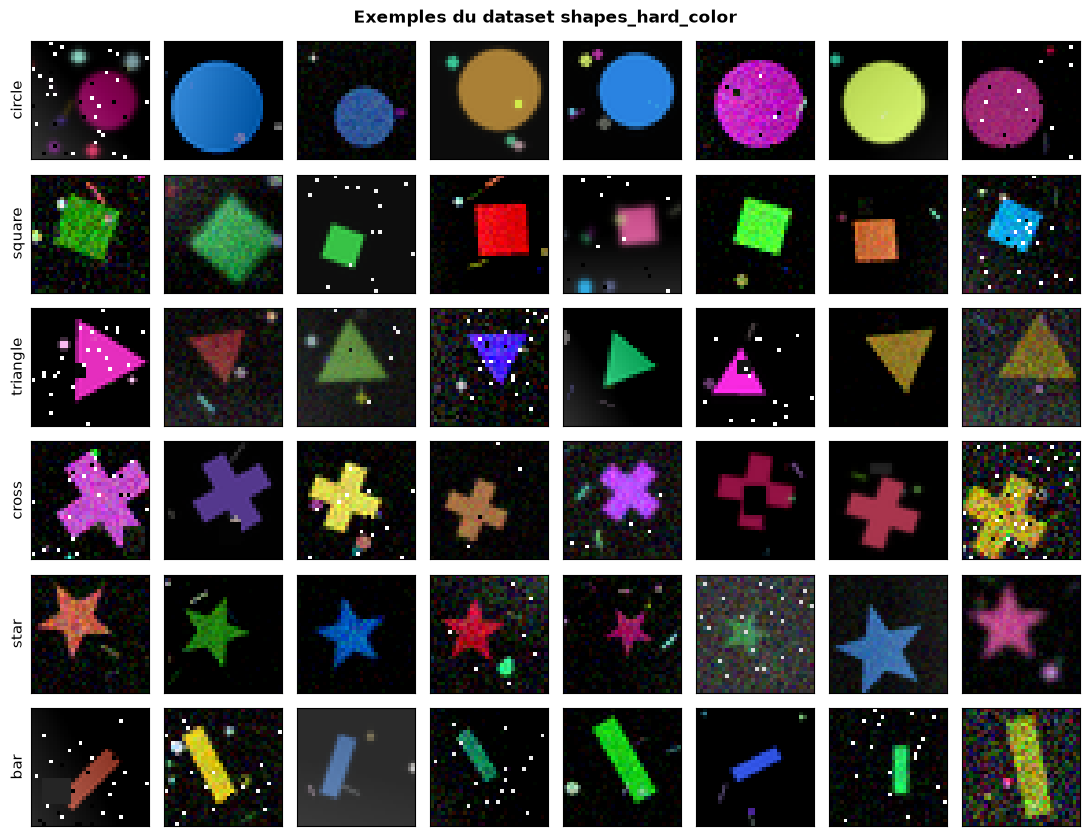

In [3]:
# Aperçu du dataset: quelques images par forme
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for r in range(6):
    picks = rng.choice(np.where(y_train == r)[0], size=8, replace=False)
    for c in range(8):
        axes[r, c].imshow(train.images[picks[c]])
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(class_names[r], fontsize=11)
fig.suptitle("Exemples du dataset shapes_hard_color", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Entraînement de K-Means (k = 6)

Choix naturel de départ : **k = 6**, une forme par cluster. On ajuste le modèle sur un
sous-échantillon aléatoire du train pour garder le notebook rapide et ré-exécutable, avec l'amorçage
k-means++ et plusieurs initialisations, en conservant la meilleure inertie (somme des distances au
carré de chaque point à son centroïde).

In [4]:
n_fit = 8000
fit_idx = rng.choice(len(X_train), size=n_fit, replace=False)
X_fit, y_fit = X_train[fit_idx], y_train[fit_idx]

kmeans = KMeans(n_clusters=6, n_init=4, max_iter=100, random_state=0)
kmeans.fit(X_fit)

print(f"Inertie    : {kmeans.inertia_:,.0f}")
print(f"Itérations : {kmeans.n_iter_}")
print(f"Centroïdes : {kmeans.centroids_.shape}")

Inertie    : 778,358
Itérations : 45
Centroïdes : (6, 3072)


### Validation contre scikit-learn

Même vérification que sur MNIST : à conditions identiques, l'inertie de notre implémentation doit
coïncider avec celle de `sklearn.cluster.KMeans`.

In [5]:
from sklearn.cluster import KMeans as SkKMeans

sk = SkKMeans(n_clusters=6, n_init=4, max_iter=100, random_state=0).fit(X_fit)
print(f"Inertie (notre implémentation) : {kmeans.inertia_:,.0f}")
print(f"Inertie (scikit-learn)         : {sk.inertia_:,.0f}")
print(f"Écart relatif                  : {abs(kmeans.inertia_ - sk.inertia_) / sk.inertia_:.4%}")

Inertie (notre implémentation) : 778,358
Inertie (scikit-learn)         : 777,933
Écart relatif                  : 0.0546%


## 3. Projection et visualisation

K-Means ne fournit pas de projection continue : sa "projection" est l'assignation de chaque image à
l'un des K clusters. On la visualise de deux façons : le dictionnaire de centroïdes vus comme
images, puis le contenu des clusters.

### 3.1 Le dictionnaire

Chaque centroïde vit dans l'espace des pixels et se réaffiche en image 32x32 RGB. Ce sont les
**prototypes** appris. On y lit surtout une couleur dominante et une tache centrale floue : moyenner
un cluster efface la forme précise mais retient la teinte.

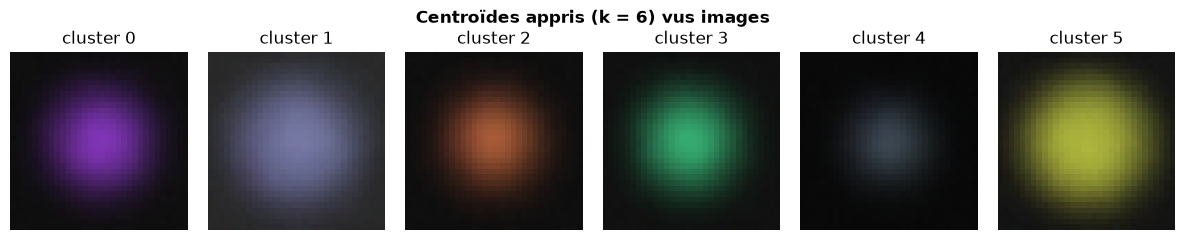

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(as_image(kmeans.centroids_[k]))
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 6) vus images", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Contenu des clusters

Pour chaque cluster, on affiche quelques images membres. Les lignes sont visuellement homogènes en
couleur mais mélangent les formes : deux images d'un même cluster partagent surtout une teinte, pas
une géométrie.

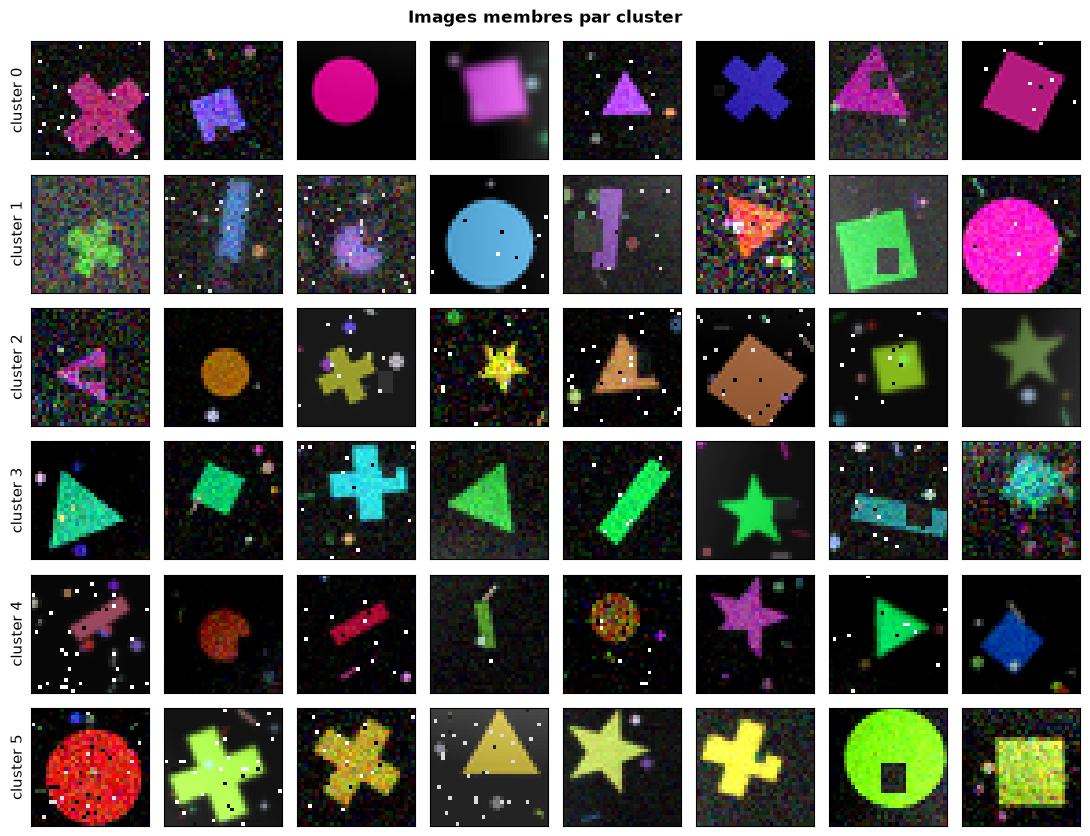

In [7]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for c in range(6):
    members = np.where(kmeans.labels_ == c)[0]
    picks = rng.choice(members, size=8, replace=False)
    for j in range(8):
        axes[c, j].imshow(train.images[fit_idx[picks[j]]])
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(f"cluster {c}", fontsize=11)
fig.suptitle("Images membres par cluster", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Compression et décompression

On encode le split de validation (chaque image devient un entier de cluster), puis on décode (chaque
entier redevient son centroïde). La fonction centralisée `compression_report` mesure le poids du
dictionnaire, celui des codes latents et la qualité de reconstruction (MSE).

Le gain est massif : un entier par image plus six centroïdes partagés, au lieu de 3072 flottants par
image. En contrepartie, toutes les images d'un cluster se reconstruisent en une seule et même tache
de couleur, d'où une MSE élevée.

In [8]:
latent = kmeans.encode(X_val)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X_val, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")

           latent_nature : discrete
          codebook_bytes : 73728
            latent_bytes : 19998
  total_compressed_bytes : 93726
          original_bytes : 245735424
       compression_ratio : 2621.849049356635
      reconstruction_mse : 0.031126463785767555


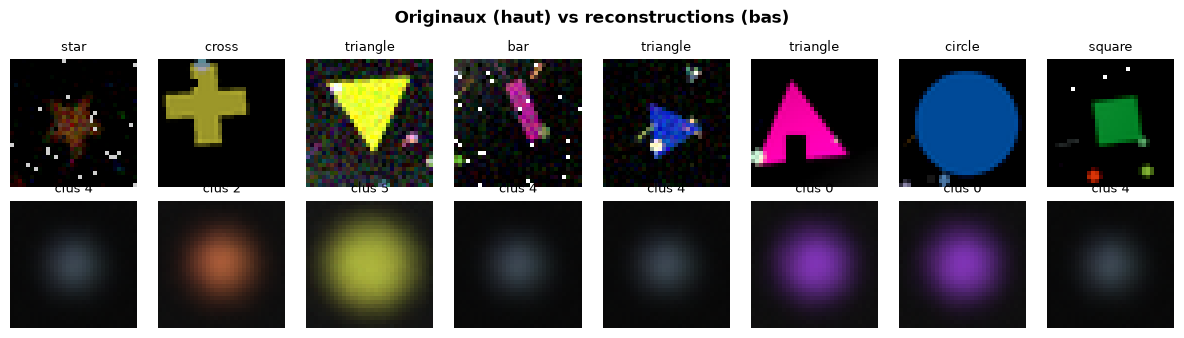

In [9]:
# Comparaison visuelle: image originale (haut) vs reconstruction par centroïde (bas)
sample_idx = rng.choice(len(X_val), size=8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for col, i in enumerate(sample_idx):
    axes[0, col].imshow(as_image(X_val[i]))
    axes[0, col].set_title(class_names[y_val[i]], fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(as_image(X_rec[i]))
    axes[1, col].set_title(f"clus {latent.array[i]}", fontsize=9)
    axes[1, col].axis("off")
fig.suptitle("Originaux (haut) vs reconstructions (bas)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Quelle valeur de k ? Méthode du coude

On balaie plusieurs k et on trace l'inertie sur un sous-échantillon. L'inertie décroît toujours
quand k augmente ; on cherche le **coude**, au-delà duquel ajouter des clusters n'apporte qu'un gain
marginal. La valeur k = 6 (le nombre de formes) n'a rien de particulier ici, puisque la structure
captée est chromatique et non géométrique.

In [10]:
subset = rng.choice(len(X_train), size=5000, replace=False)
X_sub = X_train[subset]

k_values = [2, 4, 6, 8, 12, 16, 24, 32]
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=2, max_iter=80, random_state=0).fit(X_sub)
    inertias.append(model.inertia_)
    print(f"k = {k:>2}  ->  inertie = {model.inertia_:,.0f}")

k =  2  ->  inertie = 539,295


k =  4  ->  inertie = 502,385


k =  6  ->  inertie = 478,659


k =  8  ->  inertie = 462,182


k = 12  ->  inertie = 437,332


k = 16  ->  inertie = 422,038


k = 24  ->  inertie = 402,086


k = 32  ->  inertie = 388,777


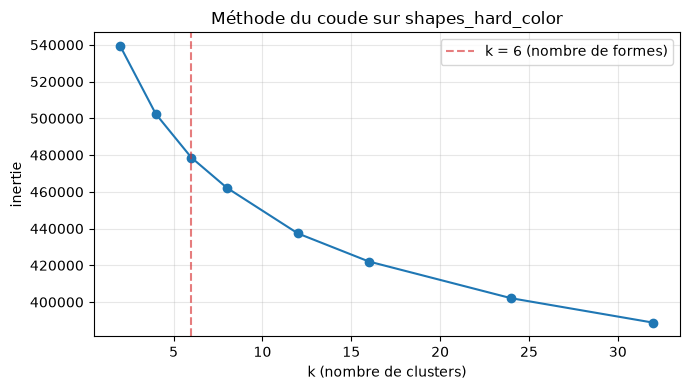

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, "o-")
plt.axvline(6, color="tab:red", linestyle="--", alpha=0.6, label="k = 6 (nombre de formes)")
plt.xlabel("k (nombre de clusters)")
plt.ylabel("inertie")
plt.title("Méthode du coude sur shapes_hard_color")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Les clusters correspondent-ils aux formes ?

K-Means ignore les étiquettes ; il regroupe par proximité euclidienne sur les pixels. On mesure a
posteriori le lien avec les formes en attribuant à chaque cluster sa forme **majoritaire**, puis en
calculant la précision de ce classement induit. On la met en regard de la cohérence chromatique des
clusters, mesurée sur le facteur génératif `hue` (teinte). La teinte étant cyclique, on utilise une
dispersion circulaire : proche de 0, le cluster est homogène en couleur ; proche de 1, il est
étalé.

In [12]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters, n_classes=6):
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=n_classes).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


def hue_dispersion(hue_values):
    """Circular dispersion in [0, 1]: 0 is perfectly concentrated, 1 fully spread."""
    resultant = np.abs(np.mean(np.exp(1j * 2 * np.pi * hue_values)))
    return 1.0 - resultant


hue = train.factors[:, factor_names.index("hue")]
hue_fit = hue[fit_idx]

acc, mapping = majority_vote_accuracy(kmeans.labels_, y_fit, 6)
print(f"Précision par vote majoritaire (forme, k = 6) : {acc:.2%}")
print(f"Niveau du hasard (6 formes équilibrées)       : {1/6:.2%}\n")
for c in range(6):
    counts = np.bincount(y_fit[kmeans.labels_ == c], minlength=6)
    purity = counts.max() / counts.sum()
    disp = hue_dispersion(hue_fit[kmeans.labels_ == c])
    print(f"cluster {c}: forme dominante = {class_names[mapping[c]]:>8}  |  pureté forme = {purity:5.1%}  |  dispersion teinte = {disp:.2f}  |  taille = {counts.sum()}")

print(f"\nDispersion de teinte, globale               : {hue_dispersion(hue_fit):.2f}")
print(f"Dispersion de teinte, moyenne intra-cluster : {np.mean([hue_dispersion(hue_fit[kmeans.labels_ == c]) for c in range(6)]):.2f}")

Précision par vote majoritaire (forme, k = 6) : 27.19%
Niveau du hasard (6 formes équilibrées)       : 16.67%

cluster 0: forme dominante =   square  |  pureté forme = 23.8%  |  dispersion teinte = 0.15  |  taille = 1197
cluster 1: forme dominante =   circle  |  pureté forme = 37.5%  |  dispersion teinte = 0.63  |  taille = 726
cluster 2: forme dominante = triangle  |  pureté forme = 18.0%  |  dispersion teinte = 0.19  |  taille = 1597
cluster 3: forme dominante =    cross  |  pureté forme = 21.5%  |  dispersion teinte = 0.18  |  taille = 1444
cluster 4: forme dominante =      bar  |  pureté forme = 30.7%  |  dispersion teinte = 0.83  |  taille = 2470
cluster 5: forme dominante =   circle  |  pureté forme = 46.3%  |  dispersion teinte = 0.12  |  taille = 566

Dispersion de teinte, globale               : 1.00
Dispersion de teinte, moyenne intra-cluster : 0.35


Augmenter k n'aide guère la forme : la précision par vote majoritaire progresse à peine, tandis que
la dispersion de teinte intra-cluster chute nettement. Les clusters supplémentaires servent donc à
raffiner la couleur, pas la géométrie. C'est l'inverse de MNIST, où augmenter k améliorait
franchement la pureté par chiffre.

In [13]:
y_sub = y_train[subset]
hue_sub = hue[subset]
print(f"{'k':>3} | {'précision forme':>16} | {'dispersion teinte intra':>24}")
for k in [6, 12, 24, 48]:
    model = KMeans(n_clusters=k, n_init=2, max_iter=80, random_state=0).fit(X_sub)
    acc_k, _ = majority_vote_accuracy(model.labels_, y_sub, k)
    disp_k = np.mean([hue_dispersion(hue_sub[model.labels_ == c]) for c in range(k) if (model.labels_ == c).any()])
    print(f"{k:>3} | {acc_k:>15.2%} | {disp_k:>24.2f}")

  k |  précision forme |  dispersion teinte intra


  6 |          27.12% |                     0.30


 12 |          28.68% |                     0.29


 24 |          30.14% |                     0.24


 48 |          32.74% |                     0.14


## 7. Génération de données

Vu comme modèle génératif, K-Means définit une loi très simple : une catégorielle sur les K codes
(les fréquences empiriques des clusters) suivie d'un décodage déterministe vers le centroïde. Pour
générer, on tire un code selon cette loi et on renvoie le centroïde correspondant.

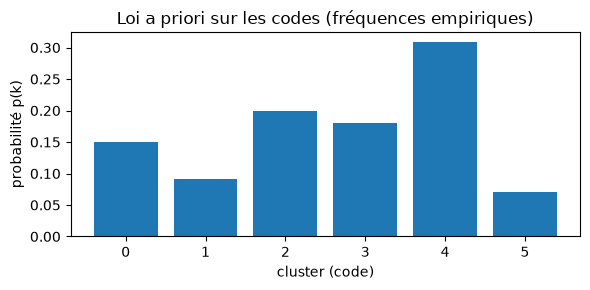

In [14]:
prior = np.bincount(kmeans.labels_, minlength=6) / len(kmeans.labels_)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(6), prior, color="tab:blue")
ax.set_xlabel("cluster (code)")
ax.set_ylabel("probabilité p(k)")
ax.set_title("Loi a priori sur les codes (fréquences empiriques)")
plt.tight_layout()
plt.show()

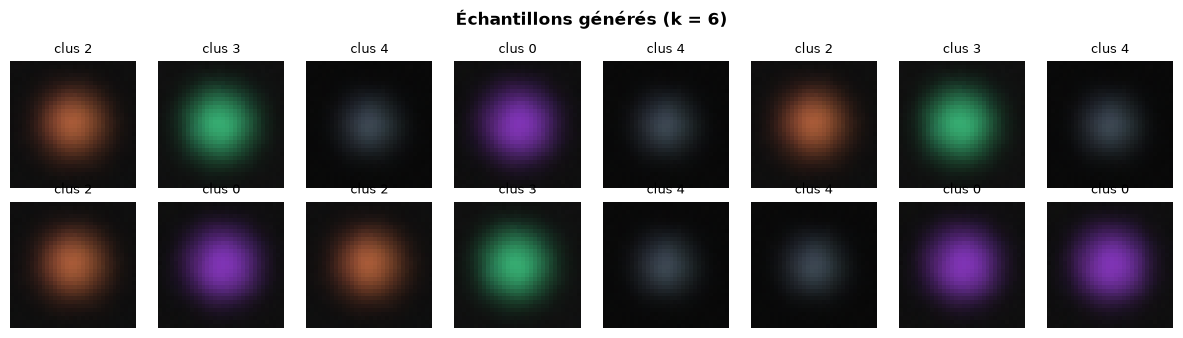

In [15]:
# Tirage de nouveaux codes selon la loi a priori, puis décodage par le centroïde
sampled = Latent(array=rng.choice(6, size=16, p=prior), nature="discrete")
generated = kmeans.decode(sampled)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, code_id, img in zip(axes.ravel(), sampled.array, generated):
    ax.imshow(as_image(img))
    ax.set_title(f"clus {code_id}", fontsize=9)
    ax.axis("off")
fig.suptitle("Échantillons générés (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

La limite est structurelle : l'ensemble des images générables se réduit exactement aux K
centroïdes. Le modèle ne produit aucune forme ni couleur inédite, seulement des répétitions de ses
prototypes pondérées par la loi a priori. Augmenter K enrichit ce vocabulaire (plus de teintes,
quelques formes moyennes distinctes) sans jamais atteindre une vraie diversité. C'est ce qui motive
les modèles à espace latent continu (PCA, AutoEncoder, puis VAE / GAN), capables d'interpoler et
d'échantillonner de nouvelles images.

## 8. Conclusions

- **Projection / visualisation** : les centroïdes sont des prototypes lisibles mais chromatiques ;
  le contenu des clusters confirme un regroupement par teinte dominante plutôt que par forme.
- **Compression / décompression** : le gain est énorme (un entier par image plus six centroïdes
  partagés) au prix d'une reconstruction très grossière, chaque cluster se résumant à une seule
  tache de couleur.
- **Génération** : le modèle génératif induit est une catégorielle sur K prototypes ; il ne crée
  rien de nouveau, ce qui illustre concrètement la faiblesse générative de K-Means.
- **Clusters vs formes** : sur pixels bruts RGB, la distance euclidienne n'est invariante à aucun
  des facteurs de variation (couleur, translation, échelle, rotation), alors que l'identité de forme
  exigerait précisément d'y être invariant. K-Means se rabat donc sur le facteur le plus contrasté,
  la couleur (dispersion de teinte intra-cluster 0.35 contre 1.00 globale), et ignore largement la
  forme (précision proche du hasard), même en augmentant k.
- **Portée pour la suite** : retirer la couleur ne suffit pas ; privée de teinte, la distance L2 se
  rabat sur la position, et la forme reste noyée. Séparer les formes demande une représentation
  explicitement invariante à la couleur et à la pose (masques normalisés, descripteurs de forme, ou
  encodeur appris avec augmentation). Une PCA ou un AutoEncoder « vanille » ne l'obtiennent pas
  d'office : entraînés sur une perte de reconstruction dominée par la couleur et la position, leurs
  premiers axes latents encodent ces facteurs plutôt que la géométrie. C'est une limite à garder en
  tête au moment de comparer les algorithmes du projet.